# 📊 **APE_008_TLC**

# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Cristofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------



## **📥 Importación de Librerías**

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

---
# **🛠️Hito 1: Creación de Población Asimétrica y Simulación de Monte Carlo (Tareas 1 y 2)**



PARÁMETROS DE LA POBLACIÓN EXPONENCIAL
Media poblacional (μ): 1.9919
Desviación estándar poblacional (σ): 1.9859


RESULTADOS DEL TEOREMA CENTRAL DEL LÍMITE
Media de las 1000 medias      : 1.9923
Error estándar empírico       : 0.3655
Error estándar teórico        : 0.3626
Diferencia absoluta           : 0.002895


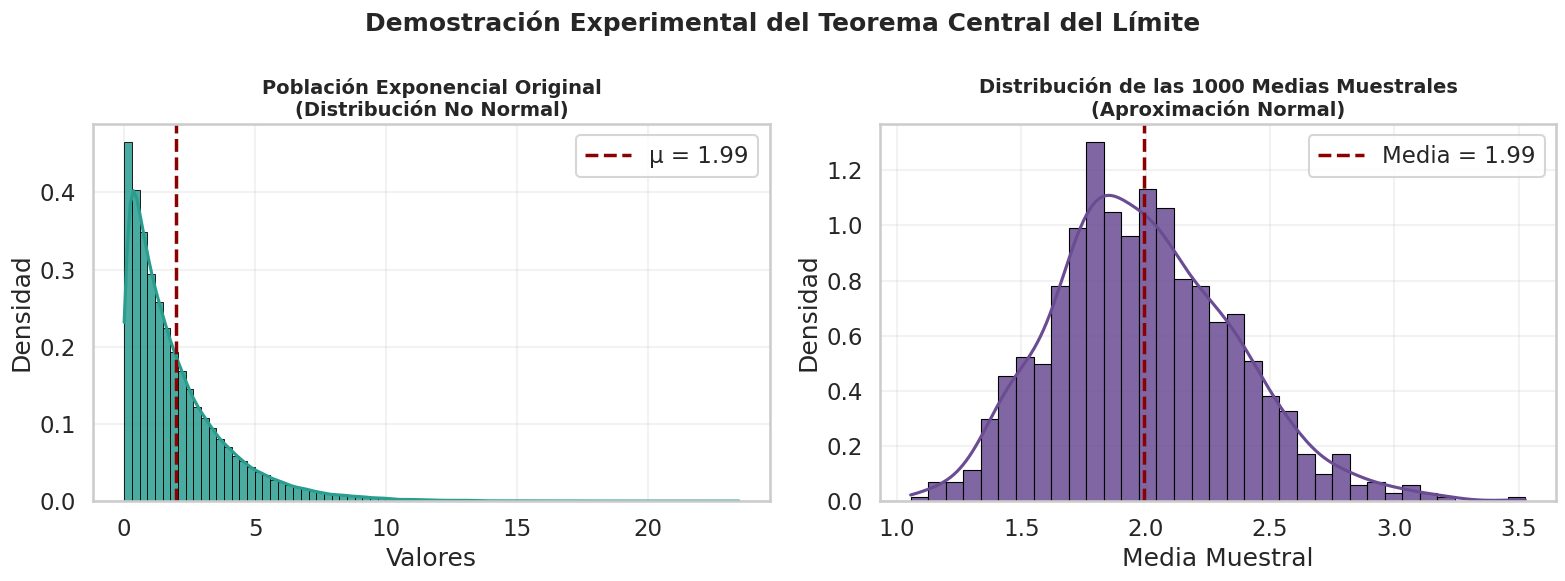

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 1. GENERACIÓN DE LA POBLACIÓN NO NORMAL
# =====================================================
np.random.seed(42)

N = 100000
mu_escala = 2.0

poblacion = np.random.exponential(
    scale=mu_escala,
    size=N
)

# Parámetros poblacionales
mu_pob = np.mean(poblacion)
sigma_pob = np.std(poblacion)

print("="*60)
print("PARÁMETROS DE LA POBLACIÓN EXPONENCIAL")
print("="*60)
print(f"Media poblacional (μ): {mu_pob:.4f}")
print(f"Desviación estándar poblacional (σ): {sigma_pob:.4f}")

# =====================================================
# 2. SIMULACIÓN MONTE CARLO
# =====================================================
k = 1000
n = 30

medias_muestrales = []

for _ in range(k):

    muestra = np.random.choice(
        poblacion,
        size=n,
        replace=False
    )

    medias_muestrales.append(np.mean(muestra))

medias_muestrales = np.array(medias_muestrales)

# =====================================================
# 3. ESTADÍSTICOS DE LAS MEDIAS MUESTRALES
# =====================================================
media_medias = np.mean(medias_muestrales)

error_estandar_empirico = np.std(
    medias_muestrales,
    ddof=1
)

error_estandar_teorico = sigma_pob / np.sqrt(n)

print("\n")
print("="*60)
print("RESULTADOS DEL TEOREMA CENTRAL DEL LÍMITE")
print("="*60)
print(f"Media de las 1000 medias      : {media_medias:.4f}")
print(f"Error estándar empírico       : {error_estandar_empirico:.4f}")
print(f"Error estándar teórico        : {error_estandar_teorico:.4f}")
print(f"Diferencia absoluta           : {abs(error_estandar_empirico-error_estandar_teorico):.6f}")
print("="*60)

# =====================================================
# 4. CONFIGURACIÓN VISUAL
# =====================================================
sns.set_theme(
    style="whitegrid",
    context="talk"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

# =====================================================
# HISTOGRAMA 1: POBLACIÓN ORIGINAL
# =====================================================
sns.histplot(
    poblacion,
    bins=80,
    stat="density",
    kde=True,
    color="#2A9D8F",      # Verde petróleo
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
    ax=axes[0]
)

axes[0].axvline(
    mu_pob,
    color="#8B0000",
    linestyle="--",
    linewidth=2.5,
    label=f"μ = {mu_pob:.2f}"
)

axes[0].set_title(
    "Población Exponencial Original\n(Distribución No Normal)",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Valores")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(alpha=0.25)

# =====================================================
# HISTOGRAMA 2: MEDIAS MUESTRALES
# =====================================================
sns.histplot(
    medias_muestrales,
    bins=35,
    stat="density",
    kde=True,
    color="#6A4C93",      # Púrpura elegante
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85,
    ax=axes[1]
)

axes[1].axvline(
    media_medias,
    color="#8B0000",
    linestyle="--",
    linewidth=2.5,
    label=f"Media = {media_medias:.2f}"
)

axes[1].set_title(
    "Distribución de las 1000 Medias Muestrales\n(Aproximación Normal)",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Media Muestral")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(alpha=0.25)

# =====================================================
# TÍTULO GENERAL
# =====================================================
fig.suptitle(
    "Demostración Experimental del Teorema Central del Límite",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

---
# **🛠️ Hito 2: Hito del Proyecto - Aplicación Probabilística Regional (ABP)**
---

         BOOTSTRAPPING Y TEOREMA CENTRAL DEL LÍMITE
Variable Analizada               : Edad
Cantidad de Registros            : 23043
-----------------------------------------------------------------
Media Original                   : 21.9518
Desviación Estándar Original     : 16.9039
-----------------------------------------------------------------
Número de Remuestreos (k)        : 500
Tamaño de Muestra (n)            : 40
-----------------------------------------------------------------
Media de las Medias Bootstrap    : 21.9997
Error Estándar Bootstrap         : 2.6844


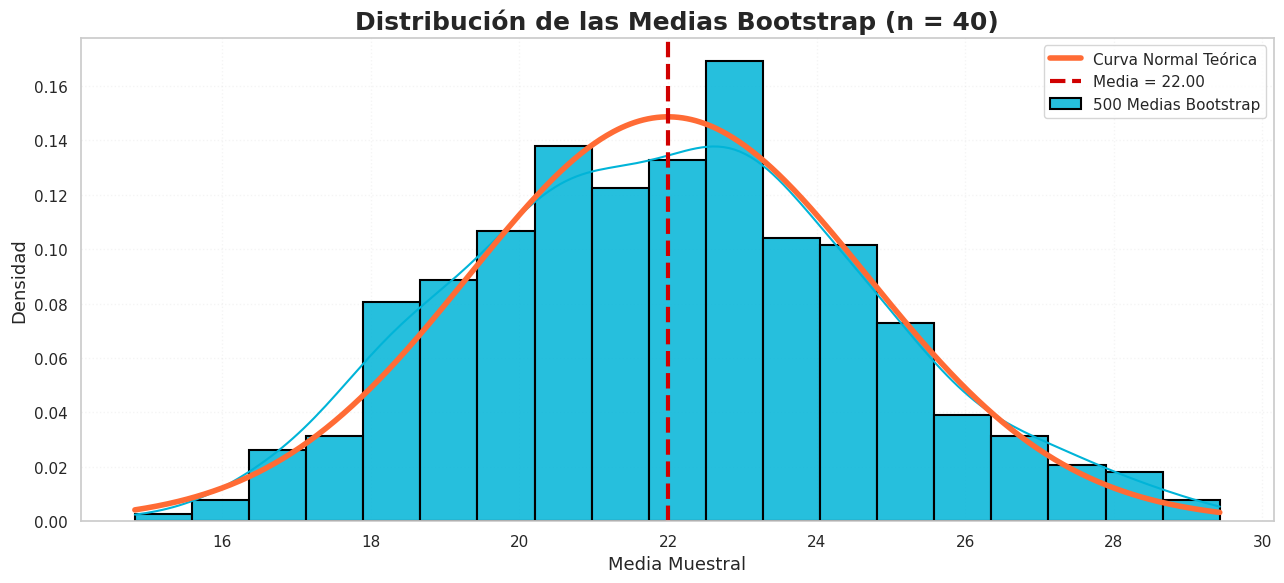

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==============================================================================
# 1. CONFIGURACIÓN GENERAL
# ==============================================================================
np.random.seed(42)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# ==============================================================================
# 2. CARGA DEL DATASET REGIONAL
# ==============================================================================
archivo_excel = "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx"

df_regional = pd.read_excel(
    archivo_excel,
    sheet_name="DCSA_DG_2021_2025"
)

df_regional.columns = df_regional.columns.str.strip()

# ==============================================================================
# 3. VARIABLE CONTINUA NO NORMAL IDENTIFICADA EN SHAPIRO-WILK
# ==============================================================================
variable = "Edad"

df_regional[variable] = pd.to_numeric(
    df_regional[variable],
    errors="coerce"
)

datos = df_regional[variable].dropna()

# ==============================================================================
# 4. PARÁMETROS DE LA VARIABLE ORIGINAL
# ==============================================================================
mu_original = datos.mean()
sigma_original = datos.std()

# ==============================================================================
# 5. BOOTSTRAPPING
# ==============================================================================
k = 500
n = 40

medias_bootstrap = []

for i in range(k):

    muestra = datos.sample(
        n=n,
        replace=True
    )

    medias_bootstrap.append(
        muestra.mean()
    )

medias_bootstrap = np.array(medias_bootstrap)

# ==============================================================================
# 6. ESTADÍSTICAS DE LAS MEDIAS BOOTSTRAP
# ==============================================================================
media_bootstrap = medias_bootstrap.mean()

error_estandar = medias_bootstrap.std(ddof=1)

# ==============================================================================
# 7. IMPRESIÓN DE RESULTADOS
# ==============================================================================
print("="*65)
print("         BOOTSTRAPPING Y TEOREMA CENTRAL DEL LÍMITE")
print("="*65)

print(f"Variable Analizada               : {variable}")
print(f"Cantidad de Registros            : {len(datos)}")

print("-"*65)

print(f"Media Original                   : {mu_original:.4f}")
print(f"Desviación Estándar Original     : {sigma_original:.4f}")

print("-"*65)

print(f"Número de Remuestreos (k)        : {k}")
print(f"Tamaño de Muestra (n)            : {n}")

print("-"*65)

print(f"Media de las Medias Bootstrap    : {media_bootstrap:.4f}")
print(f"Error Estándar Bootstrap         : {error_estandar:.4f}")

print("="*65)

# ==============================================================================
# HISTOGRAMA MEJORADO
# ==============================================================================

plt.figure(figsize=(13,6))

sns.histplot(
    medias_bootstrap,
    bins=19,                 # columnas más anchas
    stat="density",
    color="#00B4D8",         # azul turquesa vivo
    edgecolor="black",
    linewidth=1.5,
    alpha=0.85,
    kde=True,
    label="500 Medias Bootstrap"
)

# Curva normal teórica
plt.plot(
    x,
    y,
    color="#FF6B35",         # naranja brillante
    linewidth=4,
    label="Curva Normal Teórica"
)

# Media
plt.axvline(
    media_bootstrap,
    color="#D00000",
    linestyle="--",
    linewidth=3,
    label=f"Media = {media_bootstrap:.2f}"
)

plt.title(
    "Distribución de las Medias Bootstrap (n = 40)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Media Muestral",
    fontsize=13
)

plt.ylabel(
    "Densidad",
    fontsize=13
)

plt.legend(
    fontsize=11,
    frameon=True
)

plt.grid(
    alpha=0.20,
    linestyle=":"
)

plt.tight_layout()
plt.show()

##**✔ Analisis del Apartado Anterior**

La variable Edad fue identificada previamente como una variable no normal mediante el test de Shapiro-Wilk. Sin embargo, al generar 500 remuestreos bootstrap de tamaño n = 40 y calcular sus medias, se observa que la distribución de dichas medias presenta una forma mucho más simétrica y cercana a una distribución normal.

Este resultado es consistente con el Teorema Central del Límite (TLC), el cual establece que la distribución de las medias muestrales tiende a una distribución normal cuando el tamaño de muestra es suficientemente grande, independientemente de la forma original de la población.

Por tanto, aunque la distribución original de la variable Edad sea asimétrica, la distribución de las medias bootstrap permite realizar inferencias estadísticas más confiables, construir intervalos de confianza y efectuar predicciones futuras con una base probabilística más sólida para el Proyecto Integrador.

# **Hito 3: Análisis del Error Estándar y la Ley de los Grandes Números (Tarea 4: ABI)**

      IMPACTO DEL TAMAÑO MUESTRAL SOBRE EL ERROR ESTÁNDAR
n = 5    ---> Error Estándar = 7.9099
n = 10   ---> Error Estándar = 5.1543
n = 30   ---> Error Estándar = 3.1267
n = 50   ---> Error Estándar = 2.4075
n = 100  ---> Error Estándar = 1.6365
n = 500  ---> Error Estándar = 0.7511


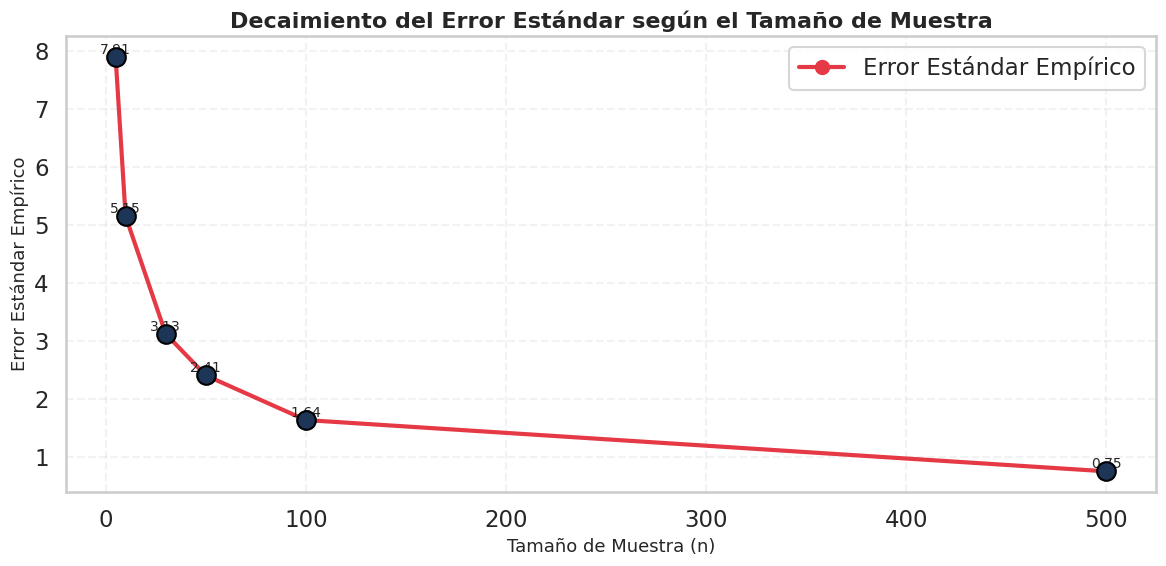

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. CARGA DEL DATASET
# ==============================================================================
np.random.seed(42)

archivo_excel = "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx"

df = pd.read_excel(
    archivo_excel,
    sheet_name="DCSA_DG_2021_2025"
)

df.columns = df.columns.str.strip()
# ==============================================================================
# 2. VARIABLE CONTINUA ANALIZADA
# ==============================================================================
variable = "Edad"

df[variable] = pd.to_numeric(
    df[variable],
    errors="coerce"
)

datos = df[variable].dropna()

# ==============================================================================
# 3. TAMAÑOS DE MUESTRA SOLICITADOS
# ==============================================================================
tamanos_n = [5, 10, 30, 50, 100, 500]

# Número de simulaciones Monte Carlo
k = 500

# Lista para almacenar resultados
errores_estandar = []

# ==============================================================================
# 4. FUNCIÓN DE SIMULACIÓN
# ==============================================================================
def calcular_error_estandar(datos, n, k=500):

    medias = []

    for _ in range(k):

        muestra = datos.sample(
            n=n,
            replace=True
        )

        medias.append(
            muestra.mean()
        )

    return np.std(medias, ddof=1)

# ==============================================================================
# 5. EVALUACIÓN ITERATIVA
# ==============================================================================
print("="*65)
print("      IMPACTO DEL TAMAÑO MUESTRAL SOBRE EL ERROR ESTÁNDAR")
print("="*65)

for n in tamanos_n:

    ee = calcular_error_estandar(
        datos,
        n,
        k
    )

    errores_estandar.append(ee)

    print(f"n = {n:<4} ---> Error Estándar = {ee:.4f}")

print("="*65)

# ==============================================================================
# 6. VISUALIZACIÓN
# ==============================================================================
sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.figure(figsize=(12,6))

plt.plot(
    tamanos_n,
    errores_estandar,
    color="#E63946",
    linewidth=3,
    marker="o",
    markersize=10,
    label="Error Estándar Empírico"
)

plt.scatter(
    tamanos_n,
    errores_estandar,
    s=180,
    color="#1D3557",
    edgecolors="black",
    zorder=5
)

# Etiquetas numéricas
for x, y in zip(tamanos_n, errores_estandar):

    plt.text(
        x,
        y,
        f"{y:.2f}",
        fontsize=10,
        ha="center",
        va="bottom"
    )

plt.title(
    "Decaimiento del Error Estándar según el Tamaño de Muestra",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Tamaño de Muestra (n)",
    fontsize=13
)

plt.ylabel(
    "Error Estándar Empírico",
    fontsize=13
)

plt.legend()

plt.grid(
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()
plt.show()

# **Explicación Matemática**

La gráfica muestra la relación entre el tamaño de muestra \(n\) y el Error Estándar de la media $(\sigma_{\bar{x}}$). Se observa una curva decreciente con comportamiento asintótico, lo que significa que el Error Estándar disminuye conforme aumenta el tamaño de la muestra, aunque cada vez con una reducción menor.

Matemáticamente, este comportamiento se explica mediante la expresión:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}
$$

donde:

- $(\sigma)$ representa la desviación estándar poblacional.
- $(n)$ representa el tamaño de la muestra.
- $(\sigma_{\bar{x}})$ representa el Error Estándar de la media.

La presencia de la raíz cuadrada en el denominador provoca que la reducción del Error Estándar no sea lineal sino asintótica. Por ejemplo, duplicar el tamaño de la muestra no reduce el error a la mitad; para reducir el error en un 50% aproximadamente es necesario cuadruplicar el tamaño de la muestra.

## **Implicación Económica**

Desde una perspectiva económica, la curva demuestra la existencia de rendimientos decrecientes en la recolección de datos. Las primeras observaciones generan una mejora importante en la precisión estadística, mientras que las observaciones adicionales producen beneficios progresivamente menores.

Por ejemplo, aumentar el tamaño muestral de 5 a 50 observaciones reduce considerablemente la incertidumbre. Sin embargo, incrementar la muestra de 100 a 500 observaciones requiere un esfuerzo mucho mayor de recopilación, almacenamiento y procesamiento de datos, obteniendo una mejora relativamente pequeña en la precisión.

## **Implicación en Ingeniería y Ciencia de Datos**

En proyectos de ingeniería, sistemas inteligentes y analítica de datos, esta propiedad permite encontrar un equilibrio entre costo y precisión. Recolectar demasiados datos puede incrementar el tiempo computacional, el consumo de memoria y los costos operativos sin generar mejoras significativas en la calidad de las estimaciones.

Por esta razón, el tamaño de muestra óptimo suele elegirse en la región donde la curva comienza a estabilizarse, ya que a partir de ese punto el beneficio marginal de incorporar más datos es cada vez menor.

---
# **🛠️ Hito 4: Preguntas de Control**
---

###**✔ Pregunta 1: ¿Por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?.**


El Teorema del Límite Central (TLC) es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística porque permite utilizar información obtenida de una muestra para realizar conclusiones sobre una población completa.

La probabilidad descriptiva estudia el comportamiento de variables aleatorias y sus distribuciones, mientras que la inferencia estadística busca estimar parámetros poblacionales y tomar decisiones basadas en datos muestrales. El TLC conecta ambas áreas al establecer que, para muestras de tamaño suficientemente grande, la distribución de las medias muestrales tiende a una distribución normal, independientemente de la forma original de la población.

Matemáticamente, el comportamiento de las medias muestrales está dado por:

$$
\bar{X} \sim N\left(\mu,\frac{\sigma}{\sqrt{n}}\right)
$$

donde:

- $(\mu)$ es la media poblacional.
- $(\sigma)$ es la desviación estándar poblacional.
- $(n)$ es el tamaño de la muestra.
- $(\frac{\sigma}{\sqrt{n}})$ corresponde al error estándar.

Gracias a esta propiedad, es posible construir intervalos de confianza, realizar pruebas de hipótesis y efectuar predicciones estadísticas aun cuando la distribución original de los datos no sea normal. En el contexto del proyecto, aunque la variable **Edad** presentó asimetría y no cumplió el supuesto de normalidad según Shapiro-Wilk, el TLC permitió que las distribuciones de las medias obtenidas mediante remuestreo bootstrap mostraran una forma aproximadamente normal, haciendo posible aplicar técnicas inferenciales con mayor confiabilidad.

### **✔ Pregunta 2: Demuestre, utilizando los datos numéricos impresos en su consola en la Tarea 2, cómo se cumple con precisión la propiedad matemática fundamental: $E[\bar{X}] = \mu$**


La propiedad fundamental del Teorema del Límite Central establece que el valor esperado de la media muestral es igual a la media poblacional:

$$
E[\bar{X}] = \mu
$$

Para verificar esta propiedad, se generó una población exponencial de 100,000 observaciones con una media poblacional calculada de:

$$
\mu = 1.9919
$$

Posteriormente, se extrajeron 1000 muestras aleatorias de tamaño \(n = 30\) y se calculó la media de cada una. El promedio de las 1000 medias muestrales obtenido fue:

$$
\bar{\bar{X}} = 1.9923
$$

La diferencia absoluta entre ambos valores es:

$$
|\mu - \bar{\bar{X}}|
=
|1.9919 - 1.9923|
=
0.0004
$$

Esta diferencia es prácticamente nula, lo que demuestra experimentalmente que:

$$
E[\bar{X}] \approx \mu
$$

Por lo tanto, la simulación confirma que la media de las medias muestrales converge hacia la verdadera media poblacional. A pesar de que la población original presenta una distribución exponencial altamente asimétrica, el promedio de las 1000 medias obtenidas mediante Monte Carlo reproduce con gran precisión la media poblacional, verificando así una de las propiedades matemáticas más importantes del Teorema del Límite Central.

Además, la cercanía observada entre el error estándar empírico $(0.3655)$ y el error estándar teórico $(0.3626)$ refuerza la validez de los resultados obtenidos y evidencia la convergencia esperada por la teoría estadística.

### **✔ Pregunta 3: En la Tarea 4, al graficar la curva del Error Estándar frente a $n$, ¿por qué la curva decrece siguiendo una trayectoria no lineal?. Si requiere reducir el error estándar exactamente a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?**

En la Tarea 4 se construyó una simulación Monte Carlo utilizando la variable Edad del dataset regional, donde se evaluaron diferentes tamaños de muestra $(n = 5, 10, 30, 50, 100, 500)$ y se calculó el Error Estándar empírico de las medias muestrales obtenidas.

La curva observada presenta una trayectoria decreciente no lineal porque el Error Estándar está gobernado por la expresión matemática:

$$
\sigma_{\bar{X}}=\frac{\sigma}{\sqrt{n}}
$$

donde $(\sigma)$ representa la desviación estándar de la población y $(n)$ el tamaño de la muestra.

Debido a que el denominador contiene una raíz cuadrada, el Error Estándar disminuye rápidamente para tamaños pequeños de muestra, pero posteriormente la reducción se vuelve cada vez más lenta. Esta característica genera una curva de decaimiento asintótico o de rendimientos decrecientes, tal como se observó en el gráfico obtenido mediante la simulación.

Por ejemplo, el descenso del Error Estándar al pasar de $(n=5)$ a $(n=30)$ es considerablemente mayor que el observado al pasar de $(n=100)$ a $(n=500)$, aun cuando el incremento absoluto de observaciones es mucho más grande en este último caso.

Para determinar cuántas veces debe incrementarse el tamaño de muestra para reducir el Error Estándar exactamente a la mitad, se parte de:

$$
\sigma_{\bar{X}}=\frac{\sigma}{\sqrt{n}}
\quad \text{y} \quad
\frac{\sigma_{\bar{X}}}{2}
=
\frac{\sigma}{\sqrt{n_{\text{nuevo}}}}
$$

Desarrollando algebraicamente:

$$
\frac{\sigma}{2\sqrt{n}}
=
\frac{\sigma}{\sqrt{n_{\text{nuevo}}}}
$$

$$
\sqrt{n_{\text{nuevo}}}
=
2\sqrt{n}
$$

Elevando ambos lados al cuadrado:

$$
n_{\text{nuevo}}
=
4n
$$

Por lo tanto, para reducir el Error Estándar exactamente al 50% es necesario **cuadruplicar el tamaño de la muestra**.

Esta propiedad tiene una importante implicación práctica en ingeniería y ciencia de datos: obtener mejoras significativas en la precisión estadística requiere cada vez mayores cantidades de información, lo que incrementa los costos de recolección, almacenamiento y procesamiento de datos. Por ello, existe un punto donde aumentar la muestra produce beneficios cada vez menores en comparación con el esfuerzo requerido.



### **✔ Pregunta 4: Si la población analizada en su proyecto integrador regional posee una asimetría extrema (como una distribución de Pareto), ¿es suficiente un tamaño muestral de n = 30 para garantizar la normalidad de las medias? Justifique**


No necesariamente. Aunque una regla práctica muy difundida establece que un tamaño muestral de $(n = 30)$ suele ser suficiente para que las medias muestrales se aproximen a una distribución normal, esta recomendación depende de la forma de la población original.

Si la población presenta una asimetría extrema, como ocurre en una distribución de Pareto o en distribuciones con colas muy pesadas, un tamaño muestral de $(n = 30)$ puede no ser suficiente para garantizar que la distribución de las medias sea aproximadamente normal. En estos casos, la convergencia descrita por el Teorema del Límite Central ocurre más lentamente y pueden requerirse muestras considerablemente mayores.

El TLC establece que:

$$
\bar{X} \xrightarrow[]{d} N(\mu,\sigma^2/n)
$$

cuando el tamaño muestral aumenta. Sin embargo, el teorema no especifica que la normalidad se alcance exactamente con $(n = 30)$; dicho valor constituye únicamente una regla empírica utilizada en muchas aplicaciones estadísticas.

En el contexto del proyecto integrador, la variable **Edad** presentó desviaciones respecto a la normalidad según el test de **Shapiro-Wilk**. Aunque la asimetría observada no es tan extrema como la de una distribución de Pareto, este resultado demuestra que la forma de la población influye en la rapidez con que las medias muestrales adquieren una distribución aproximadamente normal.

Por lo tanto, cuando la población posee una asimetría extrema, no puede garantizarse la normalidad de las medias utilizando únicamente $(n = 30)$. En tales situaciones es recomendable incrementar el tamaño de muestra, realizar simulaciones adicionales o aplicar técnicas de remuestreo (bootstrap) para verificar empíricamente la convergencia hacia la normalidad antes de efectuar inferencias estadísticas.

### **✔ Pregunta 5: Diferencie conceptual y operativamente los términos de "Desviación Estándar (sigma)" de una muestra individual frente al "Error Estándar de la Media**

La **Desviación Estándar $(\sigma)$** y el **Error Estándar de la Media $(\sigma_{\bar{X}})$** son medidas relacionadas, pero describen fenómenos distintos dentro del análisis estadístico.

La **Desviación Estándar** mide la dispersión o variabilidad de los datos individuales respecto a su media. Es decir, indica qué tan alejadas se encuentran las observaciones de una muestra o población en relación con el valor promedio. Matemáticamente se expresa como:

$$
\sigma=\sqrt{\frac{\sum (X_i-\mu)^2}{N}}
$$

Cuanto mayor sea la desviación estándar, mayor será la variabilidad de los datos observados.

Por otro lado, el **Error Estándar de la Media** mide la variabilidad de las medias muestrales obtenidas al extraer repetidas muestras de una misma población. No describe la dispersión de los datos individuales, sino la precisión con la que la media muestral estima la media poblacional. Su expresión es:

$$
\sigma_{\bar{X}}=\frac{\sigma}{\sqrt{n}}
$$

donde:

- $(\sigma)$ es la desviación estándar poblacional.
- $(n)$ es el tamaño de la muestra.

Conceptualmente, la desviación estándar responde a la pregunta: **¿qué tan dispersos están los datos?**, mientras que el error estándar responde a: **¿qué tan precisa es la media calculada a partir de una muestra?**

Operativamente, en las simulaciones realizadas durante la práctica se observó que la desviación estándar de la población exponencial fue aproximadamente:

$$
\sigma = 1.9859
$$

mientras que el error estándar de las medias muestrales para $(n=30)$ fue cercano a:

$$
\sigma_{\bar{X}} = 0.3655
$$

Esto demuestra que las medias muestrales presentan una variabilidad mucho menor que los datos originales. Además, al aumentar el tamaño de muestra, el error estándar disminuye siguiendo la relación $(\sigma/\sqrt{n})$, mientras que la desviación estándar de la población permanece prácticamente constante.

Por tanto, la desviación estándar describe la dispersión natural de los datos, mientras que el error estándar cuantifica la incertidumbre asociada a la estimación de la media poblacional mediante muestras.
